SPI Statistics:
count    14068.000000
mean         0.008557
std          1.001906
min         -1.633676
25%         -0.710070
50%         -0.260070
75%          0.492053
max          7.851246
Name: SPI, dtype: float64

Min SPI: -1.63
Max SPI: 7.85


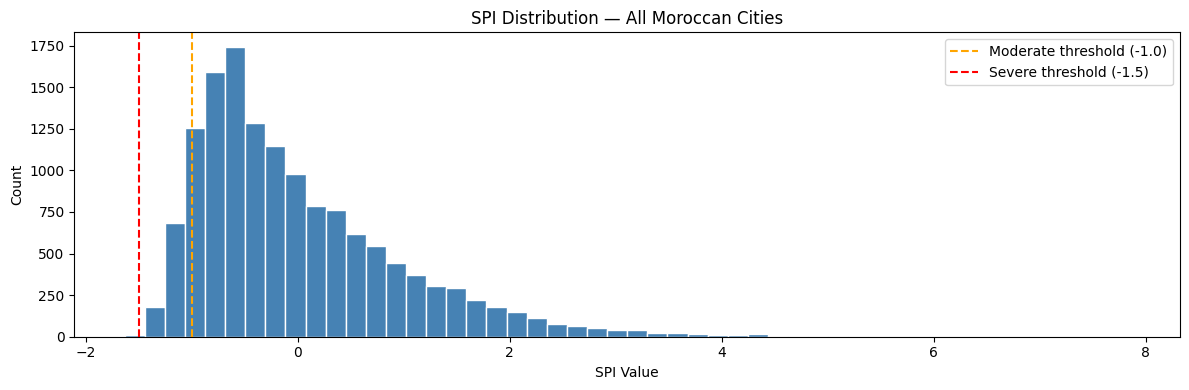


Label distribution:
drought_label
No Drought    12892
Drought        1176
Name: count, dtype: int64

Label percentage:
drought_label
No Drought    91.640603
Drought        8.359397
Name: proportion, dtype: float64


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../data/morocco_climate_features.csv")
df = pd.DataFrame(df)

print("SPI Statistics:")
print(df["SPI"].describe())
print(f"\nMin SPI: {df['SPI'].min():.2f}")
print(f"Max SPI: {df['SPI'].max():.2f}")

# Plot SPI distribution
plt.figure(figsize=(12, 4))
plt.hist(df["SPI"], bins=50, color="steelblue", edgecolor="white")
plt.axvline(-1.0, color="orange", linestyle="--", label="Moderate threshold (-1.0)")
plt.axvline(-1.5, color="red",    linestyle="--", label="Severe threshold (-1.5)")
plt.title("SPI Distribution — All Moroccan Cities")
plt.xlabel("SPI Value")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# Show exact label counts
print("\nLabel distribution:")
print(df["drought_label"].value_counts())
print("\nLabel percentage:")
print(df["drought_label"].value_counts(normalize=True) * 100)

SPI Statistics:
count    14068.000
mean         0.009
std          1.002
min         -1.634
25%         -0.710
50%         -0.260
75%          0.492
max          7.851
Name: SPI, dtype: float64

📊 Your data-driven thresholds:
   🔴 Severe   → SPI ≤ -0.58  (bottom 33%)
   🟠 Moderate → SPI ≤ 0.17  (middle 33%)
   🟢 Normal   → SPI >  0.17  (top 33%)


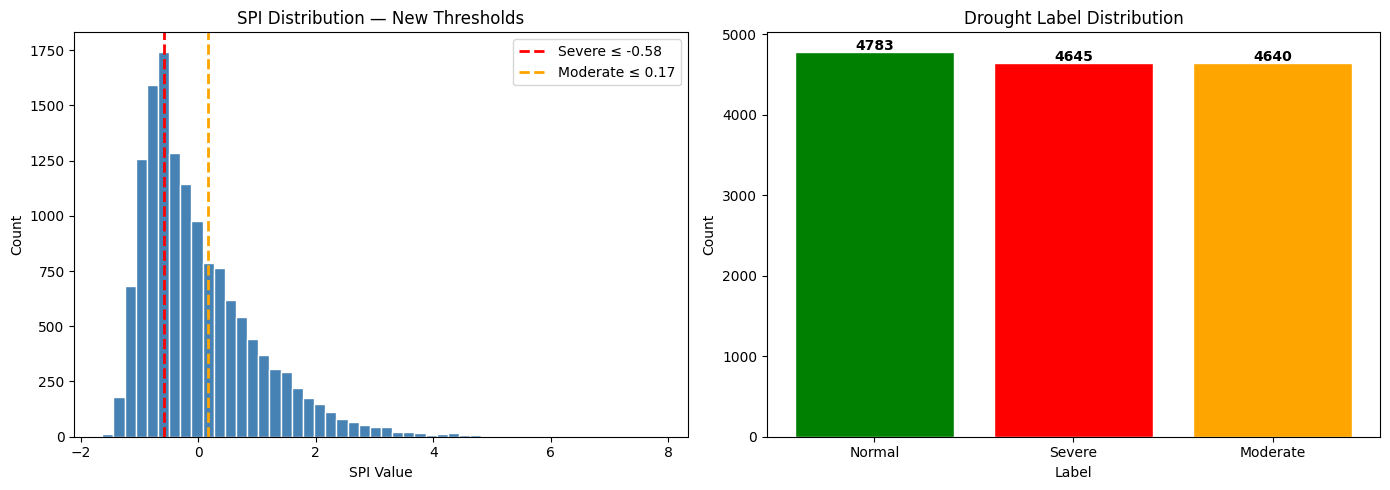


✅ Labels updated and saved

📊 Final label distribution:
drought_label
Normal      4783
Severe      4645
Moderate    4640
Name: count, dtype: int64

📊 Percentages:
drought_label
Normal      34.0
Severe      33.0
Moderate    33.0
Name: proportion, dtype: float64


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/morocco_climate_features.csv")

# ============================================
# Check actual SPI stats first
# ============================================
print("SPI Statistics:")
print(df["SPI"].describe().round(3))

# ============================================
# Percentile-based thresholds (balanced classes)
# ============================================
low  = df["SPI"].quantile(0.33)
high = df["SPI"].quantile(0.66)

print(f"\n📊 Your data-driven thresholds:")
print(f"   🔴 Severe   → SPI ≤ {low:.2f}  (bottom 33%)")
print(f"   🟠 Moderate → SPI ≤ {high:.2f}  (middle 33%)")
print(f"   🟢 Normal   → SPI >  {high:.2f}  (top 33%)")

def classify_drought(spi):
    if spi <= low:
        return "Severe"
    elif spi <= high:
        return "Moderate"
    else:
        return "Normal"

df["drought_label"] = df["SPI"].apply(classify_drought)

# ============================================
# Visualize the fix
# ============================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — SPI distribution with new thresholds
axes[0].hist(df["SPI"], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(low,  color="red",    linestyle="--", linewidth=2, label=f"Severe ≤ {low:.2f}")
axes[0].axvline(high, color="orange", linestyle="--", linewidth=2, label=f"Moderate ≤ {high:.2f}")
axes[0].set_title("SPI Distribution — New Thresholds")
axes[0].set_xlabel("SPI Value")
axes[0].set_ylabel("Count")
axes[0].legend()

# Right — Label distribution
counts = df["drought_label"].value_counts()
colors = {"Normal": "green", "Moderate": "orange", "Severe": "red"}
axes[1].bar(counts.index, counts.values,
            color=[colors[l] for l in counts.index],
            edgecolor="white")
axes[1].set_title("Drought Label Distribution")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Count")
for i, (label, count) in enumerate(counts.items()):
    axes[1].text(i, count + 20, str(count), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../assets/figures/label_distribution.png", dpi=150)
plt.show()

# ============================================
# Save updated file
# ============================================
df.to_csv("../data/morocco_climate_features.csv", index=False)

print(f"\n✅ Labels updated and saved")
print(f"\n📊 Final label distribution:")
print(df["drought_label"].value_counts())
print(f"\n📊 Percentages:")
print((df["drought_label"].value_counts(normalize=True) * 100).round(1))

📊 Label distribution:
drought_label
No Drought    12892
Drought        1176
Name: count, dtype: int64

📊 Percentages:
drought_label
No Drought    91.6
Drought        8.4
Name: count, dtype: float64

⚠️  Only 8.4% drought samples — will use class_weight='balanced' in model


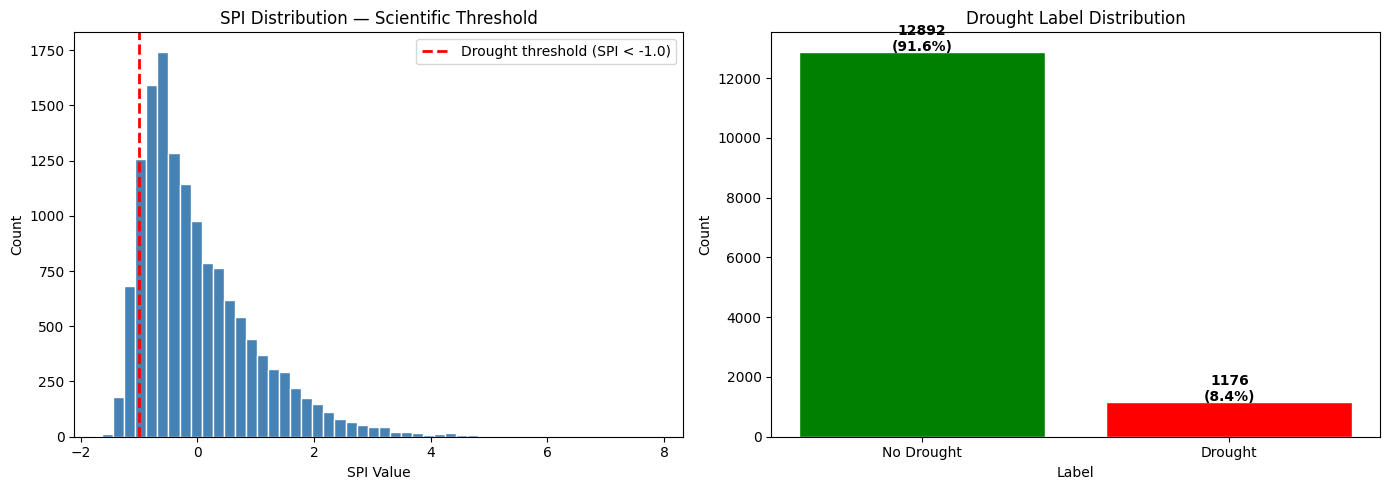


✅ Saved — 14068 rows


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/morocco_climate_features.csv")

# ============================================
# BINARY CLASSIFICATION — Drought vs No Drought
# ============================================
# Scientifically standard threshold: SPI < -1.0 = drought
def classify_drought(spi):
    if spi < -1.0:
        return "Drought"
    else:
        return "No Drought"

df["drought_label"] = df["SPI"].apply(classify_drought)

# Check distribution
counts = df["drought_label"].value_counts()
pct    = (counts / len(df) * 100).round(1)

print("📊 Label distribution:")
print(counts)
print(f"\n📊 Percentages:")
print(pct)

# ============================================
# Handle imbalance if needed
# ============================================
drought_pct = pct.get("Drought", 0)

if drought_pct < 20:
    print(f"\n⚠️  Only {drought_pct}% drought samples — will use class_weight='balanced' in model")
else:
    print(f"\n✅ {drought_pct}% drought samples — good enough for training")

# ============================================
# Visualize
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SPI distribution with threshold
axes[0].hist(df["SPI"], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(-1.0, color="red", linestyle="--", linewidth=2, label="Drought threshold (SPI < -1.0)")
axes[0].set_title("SPI Distribution — Scientific Threshold")
axes[0].set_xlabel("SPI Value")
axes[0].set_ylabel("Count")
axes[0].legend()

# Label counts
colors = ["green", "red"]
axes[1].bar(counts.index, counts.values, color=colors, edgecolor="white")
axes[1].set_title("Drought Label Distribution")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Count")
for i, (label, count) in enumerate(counts.items()):
    axes[1].text(i, count + 20, f"{count}\n({pct[label]}%)", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../assets/figures/label_distribution.png", dpi=150)
plt.show()

# Save
df.to_csv("../data/morocco_climate_features.csv", index=False)
print(f"\n✅ Saved — {len(df)} rows")

🏙️ City encoding:
   Agadir → 0
   Al Hoceima → 1
   Beni Mellal → 2
   Berkane → 3
   Biougra → 4
   Boujdour → 5
   Casablanca → 6
   Chefchaouen → 7
   Dakhla → 8
   El Jadida → 9
   Errachidia → 10
   Essaouira → 11
   Fes → 12
   Figuig → 13
   Guelmim → 14
   Ifrane → 15
   Kenitra → 16
   Khenifra → 17
   Khouribga → 18
   Ksar El Kebir → 19
   Laayoune → 20
   Larache → 21
   Marrakech → 22
   Meknes → 23
   Midelt → 24
   Mohammedia → 25
   Nador → 26
   Ouarzazate → 27
   Oued Zem → 28
   Oujda → 29
   Rabat → 30
   Safi → 31
   Salé → 32
   Semara → 33
   Settat → 34
   Tan-Tan → 35
   Tanger → 36
   Taroudant → 37
   Tata → 38
   Taza → 39
   Tetouan → 40
   Tinghir → 41
   Tiznit → 42
   Zagora → 43

✅ Features used: 17
✅ Dataset shape: (14068, 17)

Train: 11254 rows
Test:  2814 rows

Train label distribution:
drought_label
No Drought    10259
Drought         995
Name: count, dtype: int64

⚙️  Applying SMOTE...
✅ After SMOTE:
drought_label
No Drought    10259
Drought      

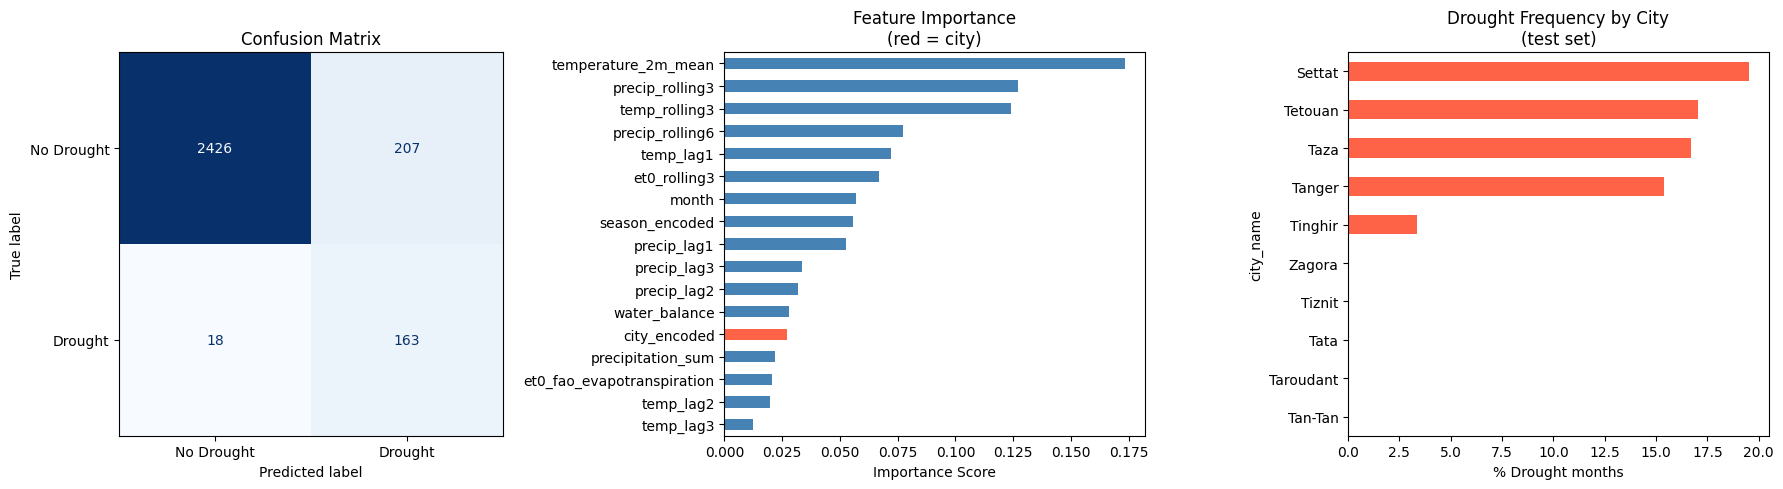


📊 Per-city performance:
   Settat               accuracy=92.7%  drought_months=24
   Tan-Tan              accuracy=91.6%  drought_months=0
   Tanger               accuracy=96.0%  drought_months=46
   Taroudant            accuracy=77.9%  drought_months=0
   Tata                 accuracy=100.0%  drought_months=0
   Taza                 accuracy=97.7%  drought_months=50
   Tetouan              accuracy=98.0%  drought_months=51
   Tinghir              accuracy=84.9%  drought_months=10
   Tiznit               accuracy=81.6%  drought_months=0
   Zagora               accuracy=100.0%  drought_months=0


In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

df = pd.read_csv("../data/morocco_climate_features.csv")

# ============================================
# ENCODE CITY — convert city names to numbers
# ============================================
le = LabelEncoder()
df["city_encoded"] = le.fit_transform(df["city"])

print("🏙️ City encoding:")
for name, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"   {name} → {code}")

# ============================================
# FEATURES — now includes city_encoded
# ============================================
features = [
    # 🏙️ Location
    "city_encoded",

    # 🌧️ Current month
    "precipitation_sum",
    "temperature_2m_mean",
    "et0_fao_evapotranspiration",
    "water_balance",

    # ⏮️ Lag features
    "precip_lag1", "precip_lag2", "precip_lag3",
    "temp_lag1",   "temp_lag2",   "temp_lag3",

    # 📊 Rolling averages
    "precip_rolling3", "precip_rolling6",
    "temp_rolling3",   "et0_rolling3",

    # 📅 Seasonality
    "month", "season_encoded"
]

X = df[features]
y = df["drought_label"]

print(f"\n✅ Features used: {len(features)}")
print(f"✅ Dataset shape: {X.shape}")

# ============================================
# TRAIN/TEST SPLIT — no shuffle (time series)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"\nTrain: {len(X_train)} rows")
print(f"Test:  {len(X_test)} rows")
print(f"\nTrain label distribution:")
print(y_train.value_counts())

# ============================================
# SMOTE — balance drought vs no drought
# ============================================
print("\n⚙️  Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"✅ After SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

# ============================================
# TRAIN RANDOM FOREST
# ============================================
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_balanced, y_train_balanced)
y_pred = model.predict(X_test)

# ============================================
# EVALUATION
# ============================================
print("\n" + "="*50)
print("📊 MODEL EVALUATION")
print("="*50)
print(classification_report(y_test, y_pred))

# ============================================
# PLOTS
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["No Drought", "Drought"])
disp = ConfusionMatrixDisplay(cm, display_labels=["No Drought", "Drought"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix")

# 2. Feature Importance
importances = pd.Series(model.feature_importances_, index=features).sort_values()
colors = ["tomato" if f == "city_encoded" else "steelblue" for f in importances.index]
importances.plot(kind="barh", ax=axes[1], color=colors)
axes[1].set_title("Feature Importance\n(red = city)")
axes[1].set_xlabel("Importance Score")

# 3. Drought prediction per city
df_test = X_test.copy()
df_test["actual"]    = y_test.values
df_test["predicted"] = y_pred
df_test["city_name"] = le.inverse_transform(df_test["city_encoded"].astype(int))

city_drought = df_test[df_test["actual"] == "Drought"].groupby("city_name").size()
city_total   = df_test.groupby("city_name").size()
city_pct     = (city_drought / city_total * 100).fillna(0).sort_values()

city_pct.plot(kind="barh", ax=axes[2], color="tomato")
axes[2].set_title("Drought Frequency by City\n(test set)")
axes[2].set_xlabel("% Drought months")

plt.tight_layout()
plt.savefig("../assets/figures/model_results.png", dpi=150)
plt.show()

# ============================================
# BONUS — Per-city accuracy
# ============================================
print("\n📊 Per-city performance:")
for city_name in sorted(df_test["city_name"].unique()):
    city_df = df_test[df_test["city_name"] == city_name]
    correct = (city_df["actual"] == city_df["predicted"]).sum()
    total   = len(city_df)
    drought = (city_df["actual"] == "Drought").sum()
    print(f"   {city_name:<20} accuracy={correct/total*100:.1f}%  drought_months={drought}")

🧪 TEST 1 — Single Custom Prediction

📍 Errachidia — August (dry summer)
   Prediction  : 🔴 DROUGHT
   Confidence  : 79.2%
   Probabilities: No Drought=20.8%  |  Drought=79.2%

📍 Tanger — January (wet winter)
   Prediction  : 🟢 NO DROUGHT
   Confidence  : 100.0%
   Probabilities: No Drought=100.0%  |  Drought=0.0%

📍 Marrakech — June (borderline)
   Prediction  : 🔴 DROUGHT
   Confidence  : 73.4%
   Probabilities: No Drought=26.6%  |  Drought=73.4%

🧪 TEST 2 — Full Year Prediction (Errachidia 2023)

Month          Rainfall     Temp     Prediction   Drought%
----------------------------------------------------------
Jan               5.7mm    8.4°C   🟢 No Drought        9.5%
Feb              33.4mm    8.3°C   🟢 No Drought        4.4%
Mar               0.2mm   18.1°C   🟢 No Drought        2.3%
Apr               6.8mm   21.5°C   🟢 No Drought        1.6%
May               7.1mm   21.8°C   🟢 No Drought       13.2%
Jun               1.3mm   27.8°C   🟢 No Drought       31.7%
Jul               0

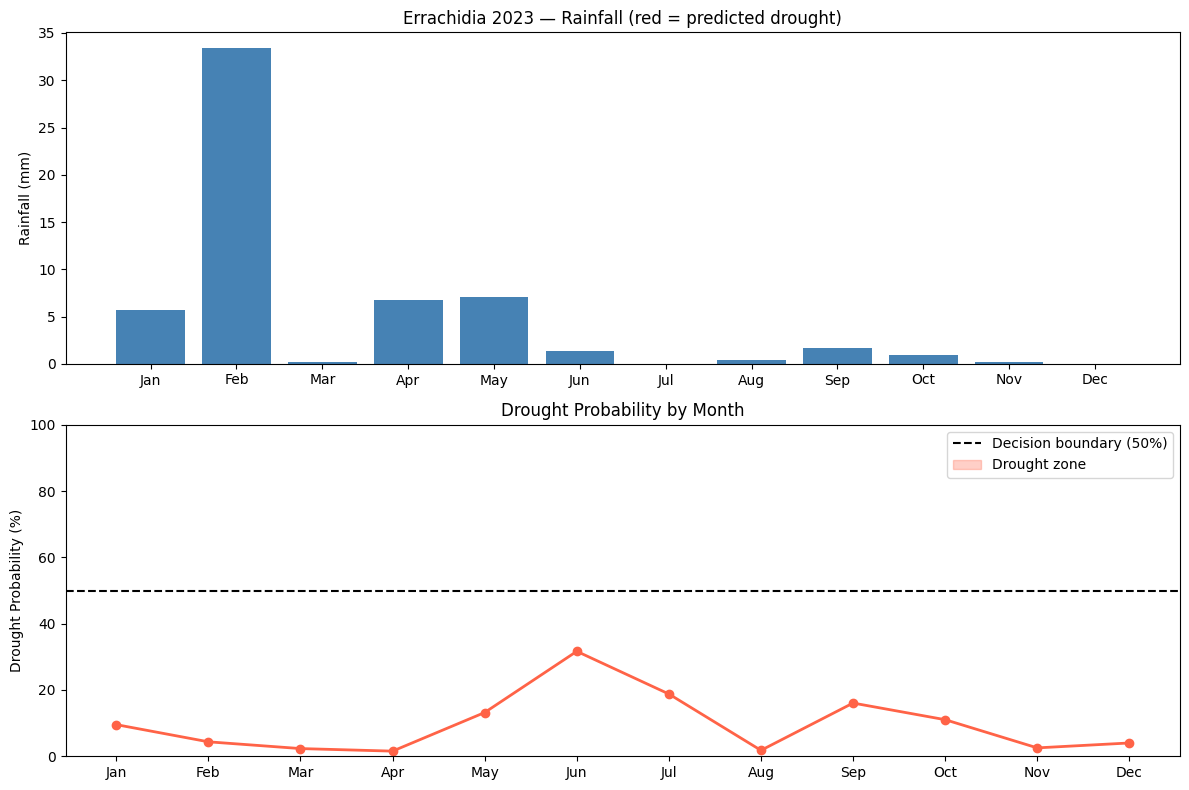


🧪 TEST 3 — Drought Risk Ranking (latest month)

Drought risk for April 2025:

City                   Risk %  Status
---------------------------------------------
Marrakech                0.0%  🟢 No Drought
Mohammedia               0.0%  🟢 No Drought
Mohammedia               0.0%  🟢 No Drought
Oujda                    0.0%  🟢 No Drought
Meknes                   0.0%  🟢 No Drought
Rabat                    0.0%  🟢 No Drought
Larache                  0.0%  🟢 No Drought
Safi                     0.0%  🟢 No Drought
Ksar El Kebir            0.0%  🟢 No Drought
Khouribga                0.0%  🟢 No Drought
Khenifra                 0.0%  🟢 No Drought
Kenitra                  0.0%  🟢 No Drought
Ifrane                   0.0%  🟢 No Drought
Salé                     0.0%  🟢 No Drought
Salé                     0.0%  🟢 No Drought
Fes                      0.0%  🟢 No Drought
Essaouira                0.0%  🟢 No Drought
Settat                   0.0%  🟢 No Drought
El Jadida                0.0%  🟢 No Drought
T

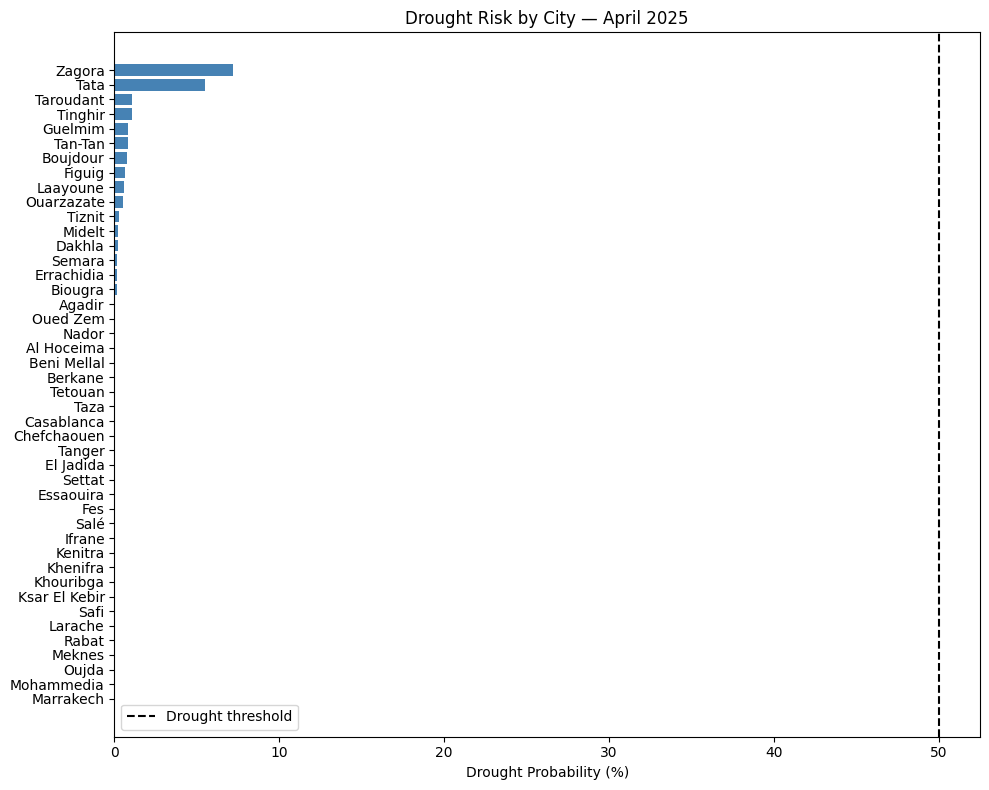

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import joblib

# ============================================
# SAVE & LOAD MODEL (do this once after training)
# ============================================
# After training, save your model:
# joblib.dump(model, "drought_model.pkl")
# joblib.dump(le, "city_encoder.pkl")

# Load them back:
# model = joblib.load("drought_model.pkl")
# le    = joblib.load("city_encoder.pkl")

# ============================================
# TEST 1 — Predict a single custom month
# ============================================
print("="*50)
print("🧪 TEST 1 — Single Custom Prediction")
print("="*50)

def predict_drought(
    city, month,
    precipitation, temperature, et0,
    precip_last1, precip_last2, precip_last3,
    temp_last1,   temp_last2,   temp_last3,
    precip_avg3,  precip_avg6,
    temp_avg3,    et0_avg3
):
    season_map = {
        12:0, 1:0, 2:0,   # Winter
        3:1,  4:1, 5:1,   # Spring
        6:2,  7:2, 8:2,   # Summer
        9:3,  10:3, 11:3  # Autumn
    }

    water_balance = precipitation - et0
    city_code     = le.transform([city])[0]
    season        = season_map[month]

    input_data = pd.DataFrame([{
        "city_encoded":               city_code,
        "precipitation_sum":          precipitation,
        "temperature_2m_mean":        temperature,
        "et0_fao_evapotranspiration": et0,
        "water_balance":              water_balance,
        "precip_lag1":                precip_last1,
        "precip_lag2":                precip_last2,
        "precip_lag3":                precip_last3,
        "temp_lag1":                  temp_last1,
        "temp_lag2":                  temp_last2,
        "temp_lag3":                  temp_last3,
        "precip_rolling3":            precip_avg3,
        "precip_rolling6":            precip_avg6,
        "temp_rolling3":              temp_avg3,
        "et0_rolling3":               et0_avg3,
        "month":                      month,
        "season_encoded":             season
    }])

    prediction   = model.predict(input_data)[0]
    probability  = model.predict_proba(input_data)[0]
    classes      = model.classes_

    return prediction, dict(zip(classes, probability))


# -----------------------------------------------
# Example A — Errachidia in August (very dry)
# -----------------------------------------------
pred, proba = predict_drought(
    city="Errachidia",  month=8,
    precipitation=0.5,  temperature=38.0,  et0=210.0,
    precip_last1=1.0,   precip_last2=0.0,  precip_last3=2.0,
    temp_last1=37.0,    temp_last2=35.0,   temp_last3=30.0,
    precip_avg3=1.2,    precip_avg6=8.0,
    temp_avg3=36.5,     et0_avg3=200.0
)

print(f"\n📍 Errachidia — August (dry summer)")
print(f"   Prediction  : {'🔴 DROUGHT' if pred == 'Drought' else '🟢 NO DROUGHT'}")
print(f"   Confidence  : {max(proba.values())*100:.1f}%")
print(f"   Probabilities: No Drought={proba.get('No Drought',0)*100:.1f}%  |  Drought={proba.get('Drought',0)*100:.1f}%")


# -----------------------------------------------
# Example B — Tanger in January (wet winter)
# -----------------------------------------------
pred, proba = predict_drought(
    city="Tanger",      month=1,
    precipitation=95.0, temperature=12.0,  et0=35.0,
    precip_last1=80.0,  precip_last2=70.0, precip_last3=60.0,
    temp_last1=13.0,    temp_last2=14.0,   temp_last3=16.0,
    precip_avg3=82.0,   precip_avg6=65.0,
    temp_avg3=13.0,     et0_avg3=38.0
)

print(f"\n📍 Tanger — January (wet winter)")
print(f"   Prediction  : {'🔴 DROUGHT' if pred == 'Drought' else '🟢 NO DROUGHT'}")
print(f"   Confidence  : {max(proba.values())*100:.1f}%")
print(f"   Probabilities: No Drought={proba.get('No Drought',0)*100:.1f}%  |  Drought={proba.get('Drought',0)*100:.1f}%")


# -----------------------------------------------
# Example C — Marrakech in June (borderline)
# -----------------------------------------------
pred, proba = predict_drought(
    city="Marrakech",   month=6,
    precipitation=3.0,  temperature=32.0,  et0=185.0,
    precip_last1=8.0,   precip_last2=15.0, precip_last3=25.0,
    temp_last1=28.0,    temp_last2=22.0,   temp_last3=18.0,
    precip_avg3=8.7,    precip_avg6=20.0,
    temp_avg3=27.3,     et0_avg3=150.0
)

print(f"\n📍 Marrakech — June (borderline)")
print(f"   Prediction  : {'🔴 DROUGHT' if pred == 'Drought' else '🟢 NO DROUGHT'}")
print(f"   Confidence  : {max(proba.values())*100:.1f}%")
print(f"   Probabilities: No Drought={proba.get('No Drought',0)*100:.1f}%  |  Drought={proba.get('Drought',0)*100:.1f}%")


# ============================================
# TEST 2 — Predict full year for one city
# ============================================
print("\n" + "="*50)
print("🧪 TEST 2 — Full Year Prediction (Errachidia 2023)")
print("="*50)

# Use real data from your dataset for Errachidia 2023
df = pd.read_csv("../data/morocco_climate_features.csv")
errachidia_2023 = df[
    (df["city"] == "Errachidia") &
    (df["time"].str.startswith("2023"))
].copy()

if len(errachidia_2023) > 0:
    # Encode city name to match model training
    errachidia_2023_encoded = errachidia_2023.copy()
    errachidia_2023_encoded["city_encoded"] = le.transform(errachidia_2023_encoded["city"])
    
    features_encoded = [
        "city_encoded", "precipitation_sum", "temperature_2m_mean",
        "et0_fao_evapotranspiration", "water_balance",
        "precip_lag1", "precip_lag2", "precip_lag3",
        "temp_lag1", "temp_lag2", "temp_lag3",
        "precip_rolling3", "precip_rolling6",
        "temp_rolling3", "et0_rolling3",
        "month", "season_encoded"
    ]

    X_2023      = errachidia_2023_encoded[features_encoded]
    predictions = model.predict(X_2023)
    probas      = model.predict_proba(X_2023)

    print(f"\n{'Month':<12} {'Rainfall':>10} {'Temp':>8} {'Prediction':>14} {'Drought%':>10}")
    print("-" * 58)

    months = ["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"]

    for i, (_, row) in enumerate(errachidia_2023.iterrows()):
        month_name = months[int(row["month"]) - 1]
        pred       = predictions[i]
        drought_p  = probas[i][list(model.classes_).index("Drought")] * 100
        icon       = "🔴" if pred == "Drought" else "🟢"
        print(f"{month_name:<12} {row['precipitation_sum']:>8.1f}mm {row['temperature_2m_mean']:>6.1f}°C   {icon} {pred:<12} {drought_p:>8.1f}%")

    # Plot the year
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    month_labels = [months[int(m)-1] for m in errachidia_2023["month"]]
    drought_probs = [probas[i][list(model.classes_).index("Drought")] * 100
                     for i in range(len(predictions))]

    # Rainfall bars
    bar_colors = ["tomato" if p == "Drought" else "steelblue" for p in predictions]
    axes[0].bar(month_labels, errachidia_2023["precipitation_sum"], color=bar_colors)
    axes[0].set_title("Errachidia 2023 — Rainfall (red = predicted drought)")
    axes[0].set_ylabel("Rainfall (mm)")

    # Drought probability line
    axes[1].plot(month_labels, drought_probs, color="tomato", marker="o", linewidth=2)
    axes[1].axhline(50, color="black", linestyle="--", label="Decision boundary (50%)")
    axes[1].fill_between(range(len(month_labels)), drought_probs, 50,
                         where=[p > 50 for p in drought_probs],
                         color="tomato", alpha=0.3, label="Drought zone")
    axes[1].set_title("Drought Probability by Month")
    axes[1].set_ylabel("Drought Probability (%)")
    axes[1].set_ylim(0, 100)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("../assets/figures/errachidia_2023_prediction.png", dpi=150)
    plt.show()
else:
    print("⚠️  No 2023 data found for Errachidia — check your dataset")


# ============================================
# TEST 3 — Compare all cities drought risk
# ============================================
print("\n" + "="*50)
print("🧪 TEST 3 — Drought Risk Ranking (latest month)")
print("="*50)

df["time"] = pd.to_datetime(df["time"], format="mixed")
latest_month = df["time"].max()
latest_data  = df[df["time"] == latest_month].copy()
latest_data_encoded = latest_data.copy()
latest_data_encoded["city_encoded"] = le.transform(latest_data_encoded["city"])

if len(latest_data) > 0:
    X_latest    = latest_data_encoded[features_encoded]
    preds       = model.predict(X_latest)
    probas_all  = model.predict_proba(X_latest)

    drought_idx = list(model.classes_).index("Drought")

    results = []
    for i, (_, row) in enumerate(latest_data.iterrows()):
        results.append({
            "city":        row["city"],
            "prediction":  preds[i],
            "drought_pct": probas_all[i][drought_idx] * 100
        })

    results_df = pd.DataFrame(results).sort_values("drought_pct", ascending=True)

    print(f"\nDrought risk for {latest_month.strftime('%B %Y')}:")
    print(f"\n{'City':<20} {'Risk %':>8}  {'Status'}")
    print("-"*45)
    for _, row in results_df.iterrows():
        icon = "🔴" if row["prediction"] == "Drought" else "🟢"
        print(f"{row['city']:<20} {row['drought_pct']:>7.1f}%  {icon} {row['prediction']}")

    # Plot ranking
    plt.figure(figsize=(10, 8))
    colors = ["tomato" if p == "Drought" else "steelblue"
              for p in results_df["prediction"]]
    plt.barh(results_df["city"], results_df["drought_pct"], color=colors)
    plt.axvline(50, color="black", linestyle="--", label="Drought threshold")
    plt.title(f"Drought Risk by City — {latest_month.strftime('%B %Y')}")
    plt.xlabel("Drought Probability (%)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("../assets/figures/city_drought_ranking.png", dpi=150)
    plt.show()

In [13]:
import joblib

# ============================================
# SAVE TRAINED MODEL & ENCODERS
# ============================================
print("💾 Saving model and encoders...")

joblib.dump(model, "drought_model.pkl")
joblib.dump(le, "city_encoder.pkl")

print("✅ Model saved: drought_model.pkl")
print("✅ City encoder saved: city_encoder.pkl")

print("\n📝 To load later:")
print("   model = joblib.load('drought_model.pkl')")
print("   le = joblib.load('city_encoder.pkl')")

💾 Saving model and encoders...
✅ Model saved: drought_model.pkl
✅ City encoder saved: city_encoder.pkl

📝 To load later:
   model = joblib.load('drought_model.pkl')
   le = joblib.load('city_encoder.pkl')
